# Rainfall Prediction
**Domain:** Environment & Energy  
**Problem Type:** Regression  
**Dataset:** Daily Rainfall at State Level — India (2009–2024)

---
## Part 1 - Problem Definition

**What is the problem?**  
Rainfall is one of the most important natural phenomena that affects agriculture, water supply, and daily life. We want to build a Machine Learning model that can **predict the actual daily rainfall (in mm)** for different Indian states based on historical patterns, the time of year, and the normal rainfall expected for that day.

**Why is this problem important?**  
Accurate rainfall prediction helps:
- Farmers plan when to sow and harvest crops
- Government prepare for floods and droughts
- Water authorities manage reservoirs and dams
- Disaster management teams to issue early warnings

**Who will benefit?**  
- **Farmers** – to plan irrigation and crop cycles
- **Government** – for flood and drought management
- **Water departments** – to manage water supply
- **General public** – for travel and daily planning

**Why is Machine Learning suitable?**  
Rainfall depends on many factors like the month, location, historical patterns, and normal seasonal rainfall. These relationships are complex and non-linear. ML models can learn these patterns from 15 years of historical data and make predictions better than simple averaging methods.

---
## Part 2 - Dataset Description

| Property | Details |
|---|---|
| Dataset Name | Daily Rainfall at State Level – India |
| Source | Kaggle / India Meteorological Department (IMD) |
| File | daily-rainfall-at-state-level.csv |
| Number of Rows | 204,876 |
| Number of Columns | 8 |
| Target Variable | actual (daily rainfall in mm) |
| Time Period | 2009 to 2024 (15 years) |
| States Covered | 36 Indian States and Union Territories |

**Columns:**
- id - row number (not useful for prediction, will be removed)
- date - date of the recording
- state_code - numeric code for the state
- state_name - name of the Indian state
- actual - actual daily rainfall in mm (Target Variable)
- rfs - rainfall forecast/scale value
- normal - normal (expected) rainfall for that day based on historical averages
- deviation - percentage deviation from normal (removed to avoid data leakage)

**Dataset Limitations:**
- About 8% of actual rainfall values are missing
- Does not include temperature, humidity, or wind data
- deviation column is derived from actual so it cannot be used as a feature
- Some states have incomplete data

---
## Step 1 - Import Libraries

In [1]:
# Importing all the libraries we need

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


---
## Step 2 - Load the Dataset

In [2]:
# Load the CSV file
df = pd.read_csv('../Dataset/Rainfall_prediction/daily-rainfall-at-state-level.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print()
df.head(10)

Dataset loaded successfully!
Shape: (204876, 8)



,id,date,state_code,state_name,actual,rfs,normal,deviation
0,0,2009-01-01,5,Uttarakhand,0.0,0.003906,2.19,-100.0
1,1,2009-01-01,18,Assam,0.0,0.000000,0.52,-100.0
2,2,2009-01-01,16,Tripura,0.0,0.000000,0.09,-100.0
3,3,2009-01-01,36,Telangana,0.0,0.000000,0.17,-100.0
4,4,2009-01-01,2,Himachal Pradesh,0.0,0.008566,3.31,-100.0
5,5,2009-01-01,1,Jammu And Kashmir,0.0,0.000000,2.42,-100.0
6,6,2009-01-01,17,Meghalaya,0.0,0.000000,0.00,NaN
7,7,2009-01-01,31,Lakshadweep,NaN,NaN,NaN,NaN
8,8,2009-01-01,27,Maharashtra,0.0,0.000000,0.31,-100.0
9,9,2009-01-01,3,Punjab,0.0,0.000000,0.40,-100.0


---
## Step 3 - Data Understanding

In [3]:
# Check data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 204876 entries, 0 to 204875
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          204876 non-null  int64  
 1   date        204876 non-null  str    
 2   state_code  204876 non-null  int64  
 3   state_name  204876 non-null  str    
 4   actual      187714 non-null  float64
 5   rfs         199011 non-null  float64
 6   normal      193358 non-null  float64
 7   deviation   173855 non-null  float64
dtypes: float64(4), int64(2), str(2)
memory usage: 12.5 MB


In [4]:
# Basic statistics
df.describe()

,id,state_code,actual,rfs,normal,deviation
count,204876.000000,204876.000000,187714.000000,199011.000000,193358.000000,173855.000000
mean,102437.500000,19.166667,3.990693,9.643683,4.654058,38.516222
std,59142.751213,11.171668,9.512507,27.504865,7.369770,1367.744520
min,0.000000,1.000000,0.000000,0.000000,0.000000,-100.000000
25%,51218.750000,9.750000,0.000000,0.000000,0.420000,-100.000000
50%,102437.500000,18.500000,0.150000,0.063856,1.870000,-89.060000
75%,153656.250000,29.250000,3.890000,5.685068,6.760000,-9.045000
max,204875.000000,38.000000,283.000000,658.765073,97.680000,362300.000000


In [5]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())
print()
print("Missing % in actual (target):")
print(round(df['actual'].isnull().sum() / len(df) * 100, 2), "%")

Missing values in each column:
id                0
date              0
state_code        0
state_name        0
actual        17162
rfs            5865
normal        11518
deviation     31021
dtype: int64

Missing % in actual (target):
8.38 %


In [6]:
# Check unique states and date range
print("Total states:", df['state_name'].nunique())
print()
print("States:", sorted(df['state_name'].unique()))
print()
print("Date range:", df['date'].min(), "to", df['date'].max())

Total states: 36

States: ['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'The Dadra And Nagar Haveli And Daman And Diu', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Date range: 2009-01-01 to 2024-07-31


In [7]:
# Target variable (actual rainfall) statistics
print("Actual Rainfall Statistics (mm):")
print("  Minimum  :", round(df['actual'].min(), 2))
print("  Maximum  :", round(df['actual'].max(), 2))
print("  Average  :", round(df['actual'].mean(), 2))
print("  Median   :", round(df['actual'].median(), 2))
print()
print("Days with zero rainfall:", (df['actual'] == 0).sum())
print("Days with rainfall > 0:", (df['actual'] > 0).sum())

Actual Rainfall Statistics (mm):
  Minimum  : 0.0
  Maximum  : 283.0
  Average  : 3.99
  Median   : 0.15

Days with zero rainfall: 78395
Days with rainfall > 0: 109319


---
## Step 4 - Data Preprocessing

In [8]:
# Step 4.1 - Drop rows where actual (target) is missing
# We cannot train without the target value

print("Rows before:", len(df))
df = df.dropna(subset=['actual'])
print("Rows after removing missing actual:", len(df))

Rows before: 204876
Rows after removing missing actual: 187714


In [9]:
# Step 4.2 - Drop columns we don't need
# - id: just a row number, not useful
# - deviation: calculated from actual rainfall, using it would be data leakage

df = df.drop(['id', 'deviation'], axis=1)
print("Dropped id and deviation columns")
print("Remaining columns:", df.columns.tolist())

Dropped id and deviation columns
Remaining columns: ['date', 'state_code', 'state_name', 'actual', 'rfs', 'normal']


In [10]:
# Step 4.3 - Extract date features from the date column
# Year, Month, Day help the model understand seasonal patterns
# Monsoon season (June-September) has much higher rainfall

df['date'] = pd.to_datetime(df['date'])
df['Year']  = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day']   = df['date'].dt.day

# Drop original date column
df = df.drop('date', axis=1)

print("Date features extracted: Year, Month, Day")
df.head(3)

Date features extracted: Year, Month, Day


,state_code,state_name,actual,rfs,normal,Year,Month,Day
0,5,Uttarakhand,0.0,0.003906,2.19,2009,1,1
1,18,Assam,0.0,0.000000,0.52,2009,1,1
2,16,Tripura,0.0,0.000000,0.09,2009,1,1


In [11]:
# Step 4.4 - Encode state_name column
# ML models only understand numbers, not text

le = LabelEncoder()
df['state_name'] = le.fit_transform(df['state_name'])

print("State encoding done!")
print("State mapping (first 10):")
for name, code in list(zip(le.classes_, le.transform(le.classes_)))[:10]:
    print(" ", name, "=", code)

State encoding done!
State mapping (first 10):
  Andhra Pradesh = 0
  Arunachal Pradesh = 1
  Assam = 2
  Bihar = 3
  Chandigarh = 4
  Chhattisgarh = 5
  Delhi = 6
  Goa = 7
  Gujarat = 8
  Haryana = 9


In [12]:
# Step 4.5 - Fill missing values in rfs and normal columns with median

df['rfs']    = df['rfs'].fillna(df['rfs'].median())
df['normal'] = df['normal'].fillna(df['normal'].median())

print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
state_code    0
state_name    0
actual        0
rfs           0
normal        0
Year          0
Month         0
Day           0
dtype: int64


In [13]:
# Step 4.6 - Remove duplicate rows

print("Rows before:", len(df))
df = df.drop_duplicates()
print("Rows after removing duplicates:", len(df))
print()
print("Final dataset shape:", df.shape)
df.head()

Rows before: 187714
Rows after removing duplicates: 187714

Final dataset shape: (187714, 8)


,state_code,state_name,actual,rfs,normal,Year,Month,Day
0,5,32,0.0,0.003906,2.19,2009,1,1
1,18,2,0.0,0.000000,0.52,2009,1,1
2,16,30,0.0,0.000000,0.09,2009,1,1
3,36,28,0.0,0.000000,0.17,2009,1,1
4,2,10,0.0,0.008566,3.31,2009,1,1


---
## Step 5 - Exploratory Data Analysis (EDA)

We will create 7 visualizations to understand the data better.

In [14]:
# Reload original data for EDA to use state names and dates
df_eda = pd.read_csv('../Dataset/Rainfall_prediction/daily-rainfall-at-state-level.csv')
df_eda = df_eda.dropna(subset=['actual'])
df_eda['date']  = pd.to_datetime(df_eda['date'])
df_eda['Month'] = df_eda['date'].dt.month
df_eda['Year']  = df_eda['date'].dt.year
print("EDA dataframe shape:", df_eda.shape)

EDA dataframe shape: (187714, 10)


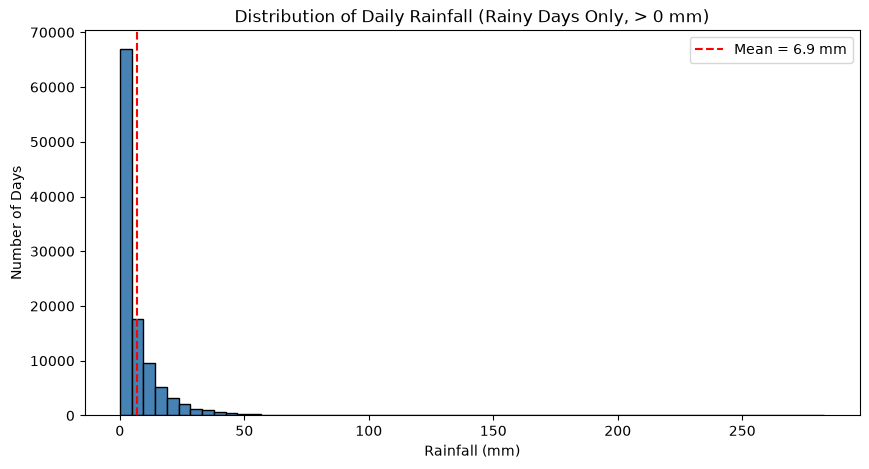

Insight: Rainfall distribution is heavily right-skewed.
Most rainy days have low rainfall (1-20mm) but some days get very heavy rain (100mm+).
Days with zero rainfall: 78395 out of 187714


In [15]:
# Visualization 1 - Histogram of Rainfall
# How is daily rainfall distributed?

plt.figure(figsize=(10, 5))
# Most days have 0 rainfall so we filter to days with rainfall > 0 for better view
rainy_days = df_eda[df_eda['actual'] > 0]['actual']
plt.hist(rainy_days, bins=60, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Rainfall (Rainy Days Only, > 0 mm)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Number of Days')
plt.axvline(rainy_days.mean(), color='red', linestyle='--',
            label='Mean = ' + str(round(rainy_days.mean(), 1)) + ' mm')
plt.legend()
plt.show()

print("Insight: Rainfall distribution is heavily right-skewed.")
print("Most rainy days have low rainfall (1-20mm) but some days get very heavy rain (100mm+).")
print("Days with zero rainfall:", (df_eda['actual'] == 0).sum(), "out of", len(df_eda))

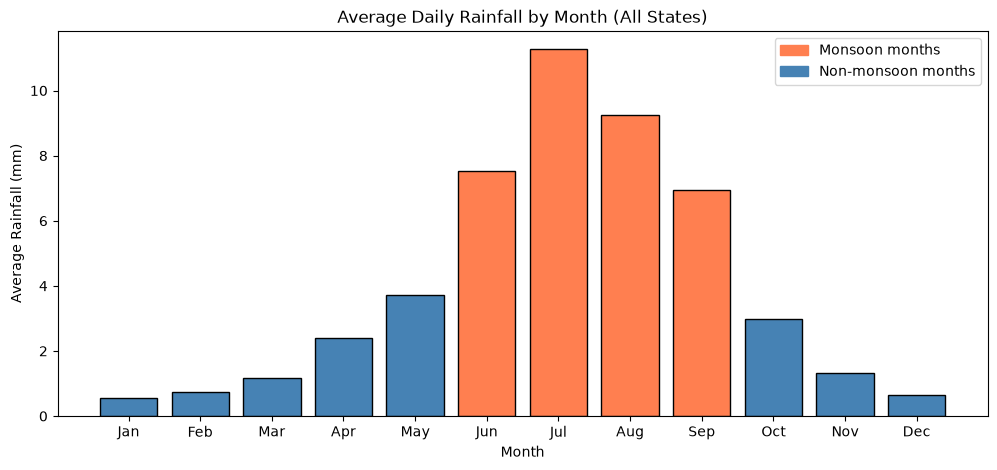

Insight: July and August have the highest average rainfall — this is the Indian monsoon season.
January and February are the driest months.


In [16]:
# Visualization 2 - Average Rainfall by Month (Bar Chart)
# Which months get the most rain?

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg = df_eda.groupby('Month')['actual'].mean()

plt.figure(figsize=(12, 5))
colors = ['steelblue' if m not in [6,7,8,9] else 'coral' for m in range(1,13)]
plt.bar(month_names, monthly_avg.values, color=colors, edgecolor='black')
plt.title('Average Daily Rainfall by Month (All States)')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color='coral', label='Monsoon months'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='Non-monsoon months')
])
plt.show()

print("Insight: July and August have the highest average rainfall — this is the Indian monsoon season.")
print("January and February are the driest months.")

<Figure size 1400x600 with 0 Axes>

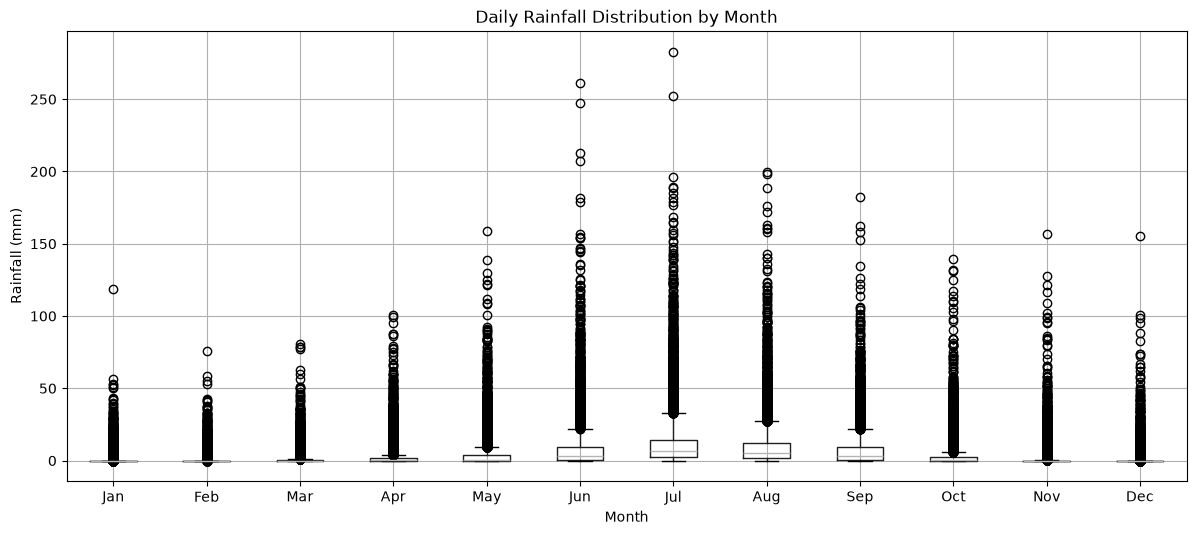

Insight: Monsoon months (Jun-Sep) have much higher spread and many outliers.
This shows that heavy rain events happen mainly during monsoon season.


In [17]:
# Visualization 3 - Box Plot of Rainfall by Month
# Shows spread and outliers in each month

plt.figure(figsize=(14, 6))
df_eda.boxplot(column='actual', by='Month', figsize=(14, 6))
plt.title('Daily Rainfall Distribution by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.xticks(ticks=range(1,13), labels=month_names)
plt.show()

print("Insight: Monsoon months (Jun-Sep) have much higher spread and many outliers.")
print("This shows that heavy rain events happen mainly during monsoon season.")

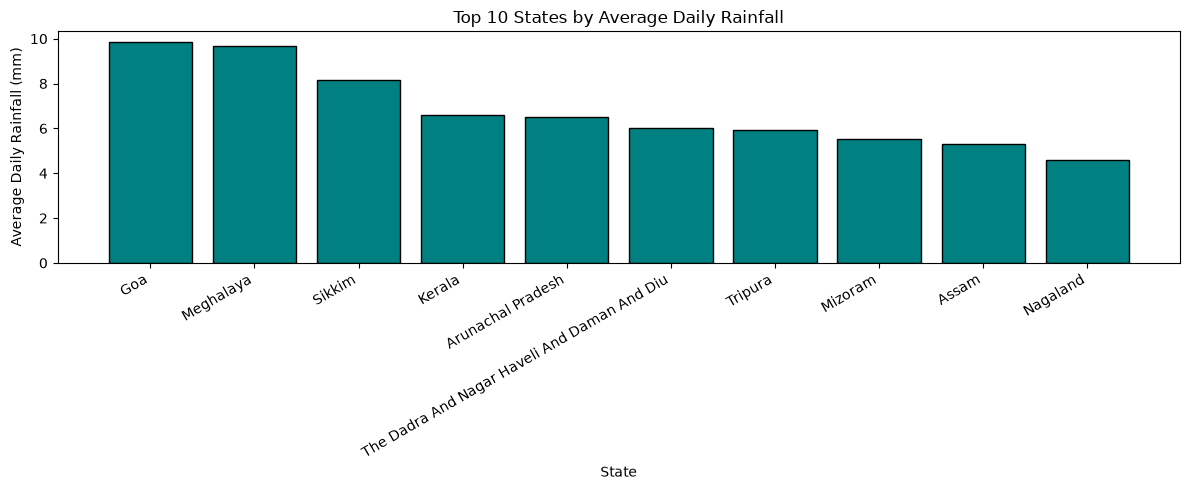

Insight: Meghalaya, Arunachal Pradesh and Sikkim get the most rainfall on average.
These states are in Northeast India which receives heavy monsoon rainfall.


In [18]:
# Visualization 4 - Top 10 States by Average Annual Rainfall (Bar Chart)

state_avg = df_eda.groupby('state_name')['actual'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(state_avg.index, state_avg.values, color='teal', edgecolor='black')
plt.title('Top 10 States by Average Daily Rainfall')
plt.xlabel('State')
plt.ylabel('Average Daily Rainfall (mm)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("Insight: Meghalaya, Arunachal Pradesh and Sikkim get the most rainfall on average.")
print("These states are in Northeast India which receives heavy monsoon rainfall.")

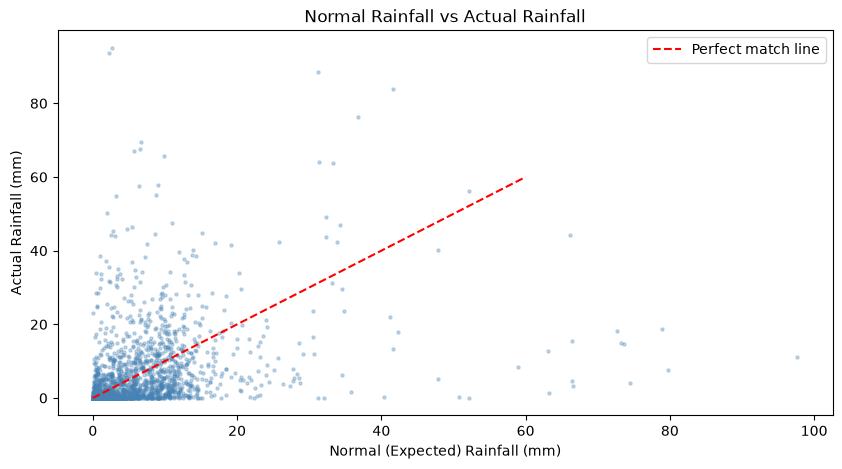

Insight: There is a positive relationship between normal and actual rainfall.
However actual rainfall varies a lot from the expected normal — making ML necessary.


In [19]:
# Visualization 5 - Scatter Plot: Normal vs Actual Rainfall
# Does actual rainfall follow the expected normal pattern?

sample = df_eda[df_eda['actual'] < 100].sample(3000, random_state=42)

plt.figure(figsize=(10, 5))
plt.scatter(sample['normal'], sample['actual'], alpha=0.3, s=5, color='steelblue')
plt.plot([0, 60], [0, 60], 'r--', label='Perfect match line')
plt.title('Normal Rainfall vs Actual Rainfall')
plt.xlabel('Normal (Expected) Rainfall (mm)')
plt.ylabel('Actual Rainfall (mm)')
plt.legend()
plt.show()

print("Insight: There is a positive relationship between normal and actual rainfall.")
print("However actual rainfall varies a lot from the expected normal — making ML necessary.")

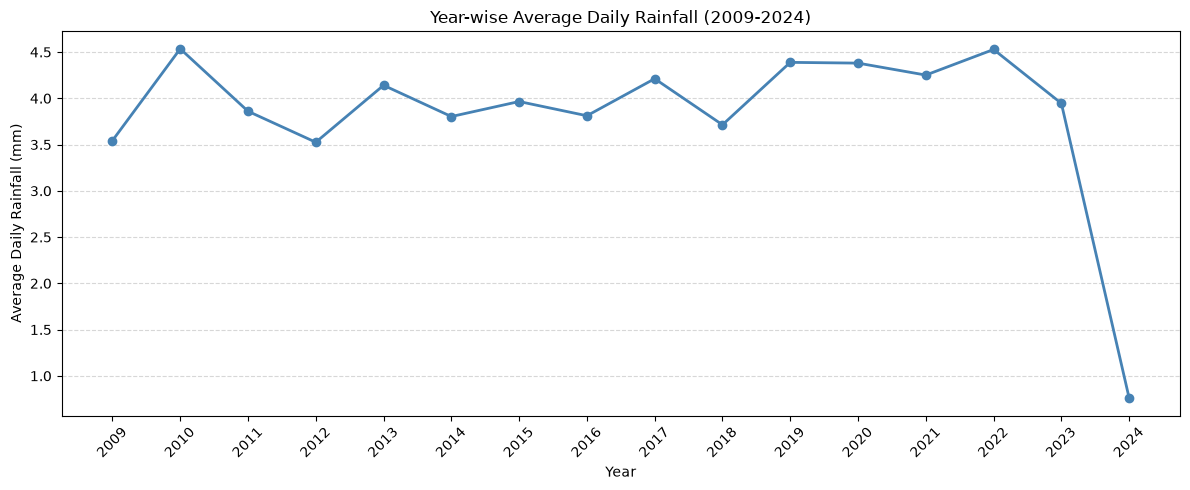

Insight: Rainfall varies year to year but stays within a certain range.
Some years have higher average rainfall (wet years) and some have lower (drought years).


In [20]:
# Visualization 6 - Line Chart: Yearly Average Rainfall Trend

yearly_avg = df_eda.groupby('Year')['actual'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_avg.index, yearly_avg.values, color='steelblue',
         marker='o', markersize=6, linewidth=2)
plt.title('Year-wise Average Daily Rainfall (2009-2024)')
plt.xlabel('Year')
plt.ylabel('Average Daily Rainfall (mm)')
plt.xticks(yearly_avg.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Insight: Rainfall varies year to year but stays within a certain range.")
print("Some years have higher average rainfall (wet years) and some have lower (drought years).")

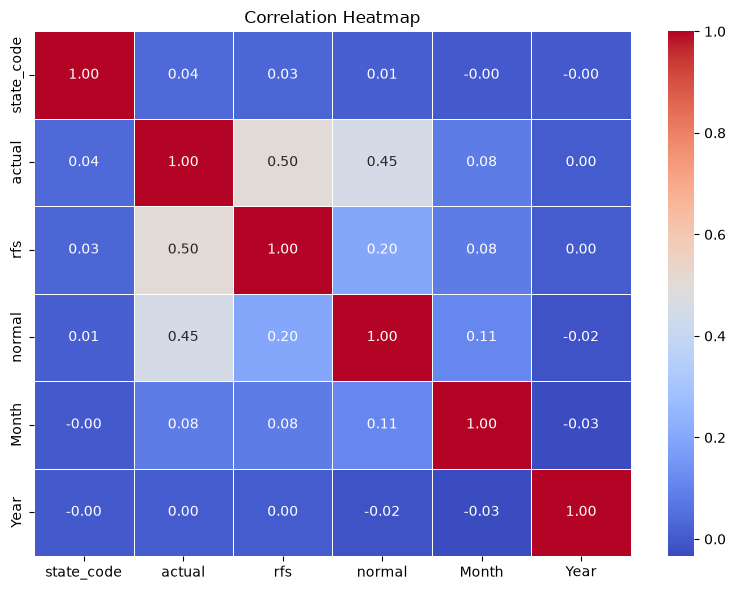

Insight: 'normal' and 'rfs' have the highest correlation with actual rainfall.
Month also has a decent correlation showing the seasonal effect of monsoon.


In [21]:
# Visualization 7 - Correlation Heatmap

num_cols = ['state_code', 'actual', 'rfs', 'normal', 'Month', 'Year']
df_corr = df_eda[num_cols].copy()
df_corr['Month'] = df_eda['Month']
df_corr['Year']  = df_eda['Year']
corr = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Insight: 'normal' and 'rfs' have the highest correlation with actual rainfall.")
print("Month also has a decent correlation showing the seasonal effect of monsoon.")

---
## Step 6 - Feature Selection and Train-Test Split

In [22]:
# Separate features (X) and target (y)
X = df.drop('actual', axis=1)
y = df['actual']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print()
print("Feature columns used:")
print(list(X.columns))

Features (X) shape: (187714, 7)
Target (y) shape: (187714,)

Feature columns used:
['state_code', 'state_name', 'rfs', 'normal', 'Year', 'Month', 'Day']


In [23]:
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train))
print("Testing set size :", len(X_test))

Training set size: 150171
Testing set size : 37543


In [24]:
# Feature Scaling for Linear Regression
# Tree-based models (Decision Tree, Random Forest, Gradient Boosting)
# do not need scaling but Linear Regression does

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Feature scaling done!")

Feature scaling done!


---
## Step 7 - Model Training

In [25]:
# Model 1 - Linear Regression
# Baseline model that draws a line through the data

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("Linear Regression - done!")

Linear Regression - done!


In [26]:
# Model 2 - Decision Tree Regression
# Captures non-linear relationships using if-else splits

model_dt = DecisionTreeRegressor(max_depth=8, random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

print("Decision Tree Regression - done!")

Decision Tree Regression - done!


In [27]:
# Model 3 - Random Forest Regression
# 100 decision trees voting together - more accurate

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("Random Forest Regression - done!")

Random Forest Regression - done!


In [28]:
# Model 4 - Gradient Boosting Regression
# Trees built one by one, each fixing errors of previous ones

model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)

print("Gradient Boosting Regression - done!")

Gradient Boosting Regression - done!


---
## Step 8 - Model Evaluation

In [29]:
# Calculate metrics for all models

# Linear Regression
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

# Decision Tree
mae_dt  = mean_absolute_error(y_test, y_pred_dt)
mse_dt  = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt   = r2_score(y_test, y_pred_dt)

# Random Forest
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

# Gradient Boosting
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
mse_gb  = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb   = r2_score(y_test, y_pred_gb)

print("Metrics calculated!")

Metrics calculated!


In [30]:
# Print results

print("="*55)
print("Linear Regression")
print("  MAE  :", round(mae_lr, 2), "mm")
print("  MSE  :", round(mse_lr, 2))
print("  RMSE :", round(rmse_lr, 2), "mm")
print("  R2   :", round(r2_lr, 4))

print("="*55)
print("Decision Tree")
print("  MAE  :", round(mae_dt, 2), "mm")
print("  MSE  :", round(mse_dt, 2))
print("  RMSE :", round(rmse_dt, 2), "mm")
print("  R2   :", round(r2_dt, 4))

print("="*55)
print("Random Forest")
print("  MAE  :", round(mae_rf, 2), "mm")
print("  MSE  :", round(mse_rf, 2))
print("  RMSE :", round(rmse_rf, 2), "mm")
print("  R2   :", round(r2_rf, 4))

print("="*55)
print("Gradient Boosting")
print("  MAE  :", round(mae_gb, 2), "mm")
print("  MSE  :", round(mse_gb, 2))
print("  RMSE :", round(rmse_gb, 2), "mm")
print("  R2   :", round(r2_gb, 4))

Linear Regression
  MAE  : 3.03 mm
  MSE  : 57.19
  RMSE : 7.56 mm
  R2   : 0.3673
Decision Tree
  MAE  : 1.13 mm
  MSE  : 11.4
  RMSE : 3.38 mm
  R2   : 0.8739
Random Forest
  MAE  : 0.07 mm
  MSE  : 0.84
  RMSE : 0.92 mm
  R2   : 0.9907
Gradient Boosting
  MAE  : 1.85 mm
  MSE  : 23.12
  RMSE : 4.81 mm
  R2   : 0.7443


---
## Step 9 - Model Comparison

In [31]:
# Model comparison table

comparison = {
    'Model'   : ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE'     : [round(mae_lr,2),  round(mae_dt,2),  round(mae_rf,2),  round(mae_gb,2)],
    'MSE'     : [round(mse_lr,2),  round(mse_dt,2),  round(mse_rf,2),  round(mse_gb,2)],
    'RMSE'    : [round(rmse_lr,2), round(rmse_dt,2), round(rmse_rf,2), round(rmse_gb,2)],
    'R2 Score': [round(r2_lr,4),   round(r2_dt,4),   round(r2_rf,4),   round(r2_gb,4)]
}

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

            Model  MAE   MSE  RMSE  R2 Score
Linear Regression 3.03 57.19  7.56    0.3673
    Decision Tree 1.13 11.40  3.38    0.8739
    Random Forest 0.07  0.84  0.92    0.9907
Gradient Boosting 1.85 23.12  4.81    0.7443


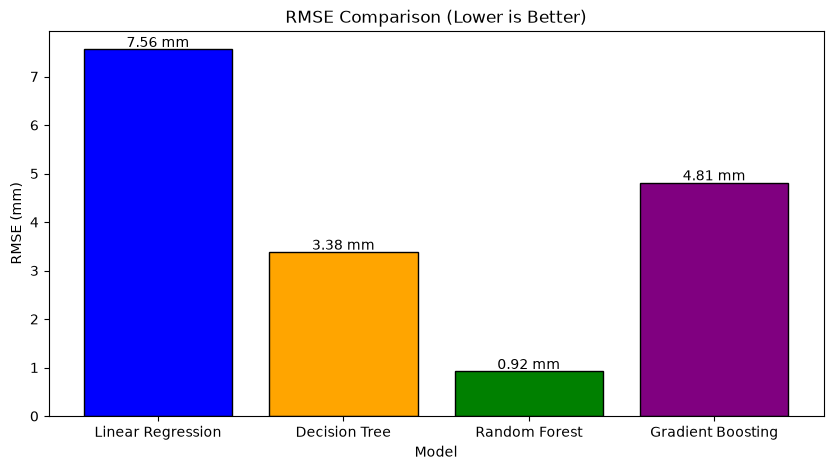

In [32]:
# RMSE comparison chart
models    = comparison_df['Model']
rmse_vals = comparison_df['RMSE']

plt.figure(figsize=(10, 5))
plt.bar(models, rmse_vals, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('RMSE Comparison (Lower is Better)')
plt.xlabel('Model')
plt.ylabel('RMSE (mm)')
for i in range(len(models)):
    plt.text(i, rmse_vals.values[i] + 0.05, str(rmse_vals.values[i]) + ' mm',
             ha='center', fontsize=10)
plt.show()

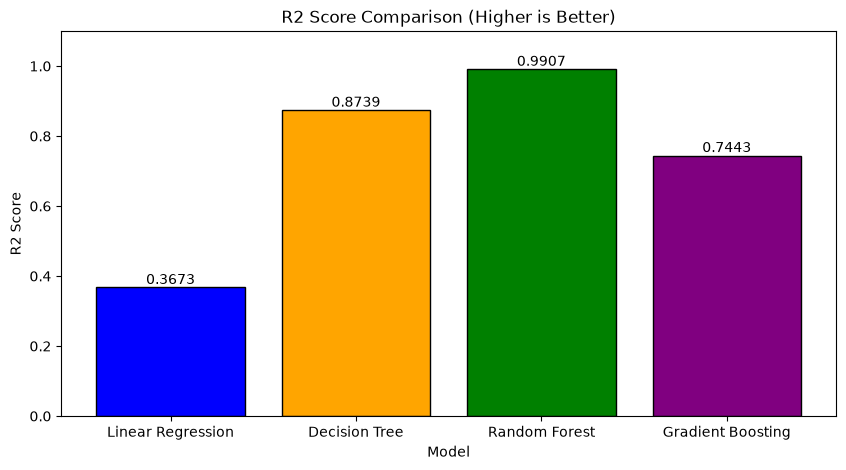

In [33]:
# R2 Score comparison chart
r2_vals = comparison_df['R2 Score']

plt.figure(figsize=(10, 5))
plt.bar(models, r2_vals, color=['blue', 'orange', 'green', 'purple'], edgecolor='black')
plt.title('R2 Score Comparison (Higher is Better)')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
for i in range(len(models)):
    plt.text(i, r2_vals.values[i] + 0.01, str(r2_vals.values[i]),
             ha='center', fontsize=10)
plt.show()

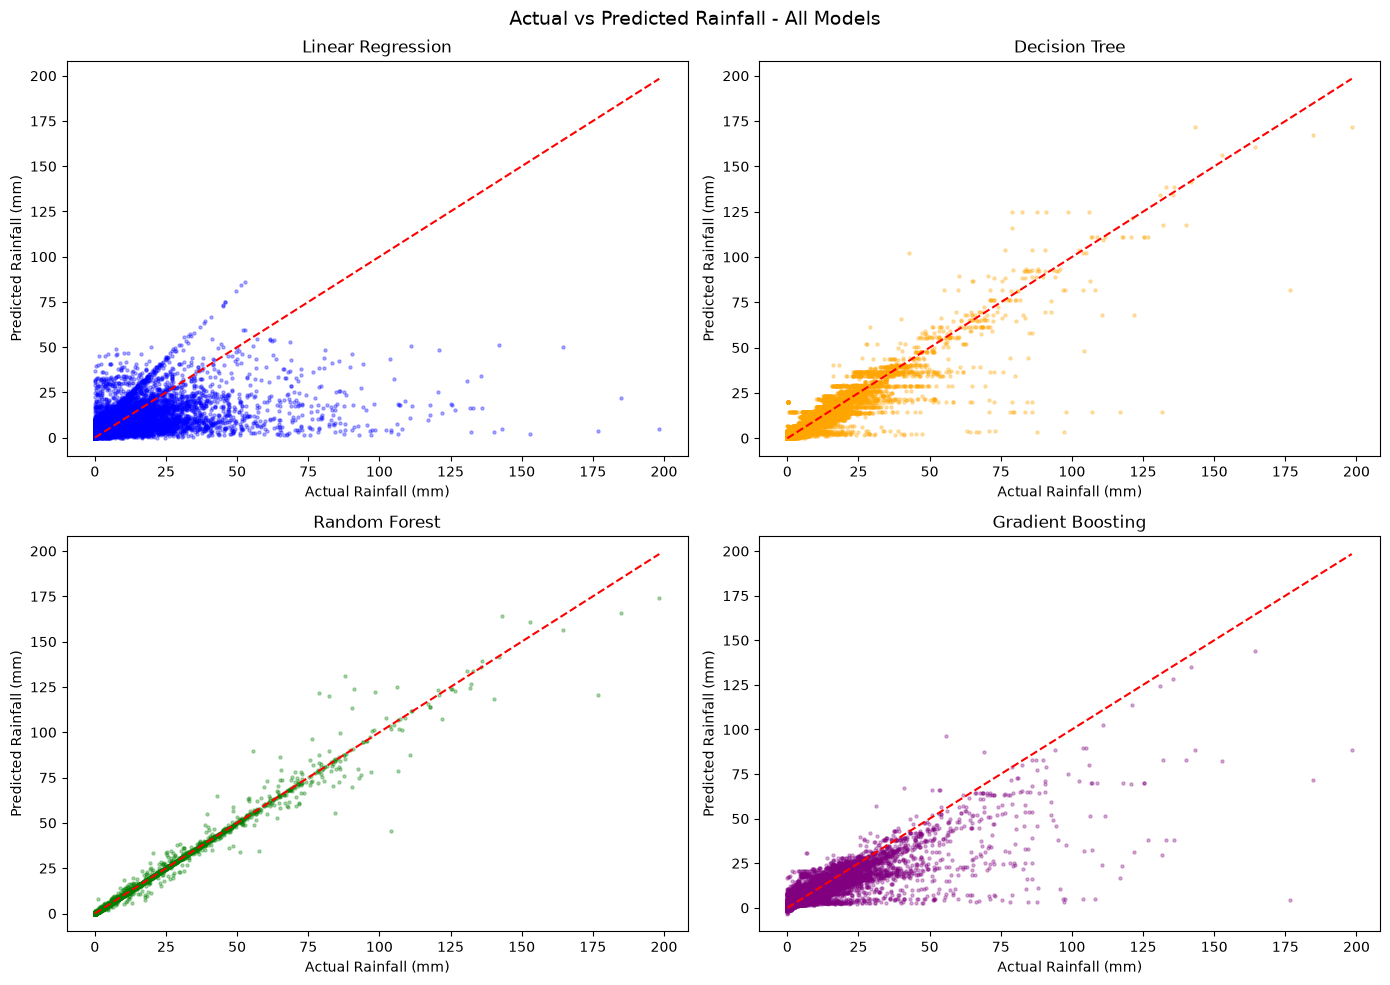

In [34]:
# Actual vs Predicted plots for all models

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].scatter(y_test, y_pred_lr, alpha=0.3, s=5, color='blue')
axes[0][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][0].set_title('Linear Regression')
axes[0][0].set_xlabel('Actual Rainfall (mm)')
axes[0][0].set_ylabel('Predicted Rainfall (mm)')

axes[0][1].scatter(y_test, y_pred_dt, alpha=0.3, s=5, color='orange')
axes[0][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0][1].set_title('Decision Tree')
axes[0][1].set_xlabel('Actual Rainfall (mm)')
axes[0][1].set_ylabel('Predicted Rainfall (mm)')

axes[1][0].scatter(y_test, y_pred_rf, alpha=0.3, s=5, color='green')
axes[1][0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][0].set_title('Random Forest')
axes[1][0].set_xlabel('Actual Rainfall (mm)')
axes[1][0].set_ylabel('Predicted Rainfall (mm)')

axes[1][1].scatter(y_test, y_pred_gb, alpha=0.3, s=5, color='purple')
axes[1][1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1][1].set_title('Gradient Boosting')
axes[1][1].set_xlabel('Actual Rainfall (mm)')
axes[1][1].set_ylabel('Predicted Rainfall (mm)')

plt.suptitle('Actual vs Predicted Rainfall - All Models', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 10 - Best Model and Feature Importance

In [35]:
# Select best model based on highest R2 Score
best_index = comparison_df['R2 Score'].idxmax()
best_row   = comparison_df.loc[best_index]

print("Best Model :", best_row['Model'])
print("MAE        :", best_row['MAE'], "mm")
print("RMSE       :", best_row['RMSE'], "mm")
print("R2 Score   :", best_row['R2 Score'])
print()
print("Why this model is best:")
print("It has the highest R2 Score meaning it explains the most variance in rainfall.")
print("It also has the lowest RMSE meaning its predictions are closest to actual rainfall.")

Best Model : Random Forest
MAE        : 0.07 mm
RMSE       : 0.92 mm
R2 Score   : 0.9907

Why this model is best:
It has the highest R2 Score meaning it explains the most variance in rainfall.
It also has the lowest RMSE meaning its predictions are closest to actual rainfall.


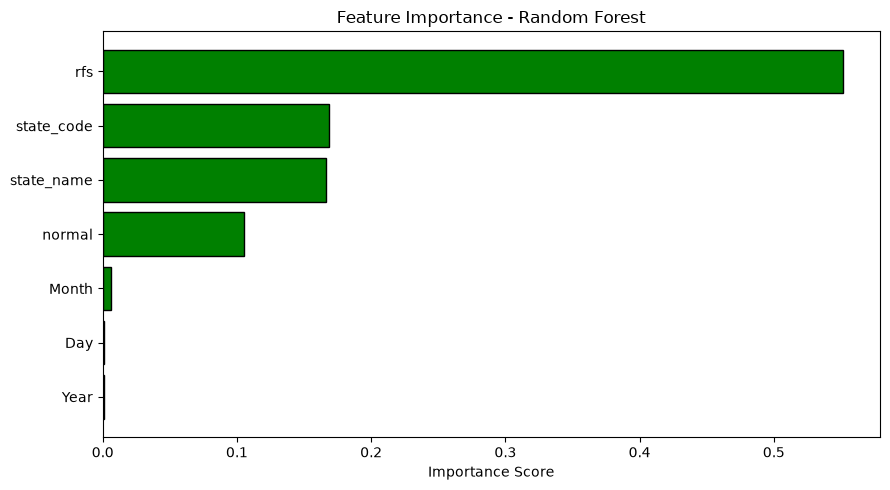

Top 3 most important features:
 - rfs ( 55.2 % importance)
 - state_code ( 16.8 % importance)
 - state_name ( 16.6 % importance)


In [36]:
# Feature Importance from Random Forest

feat_names   = X_train.columns
importances  = model_rf.feature_importances_

imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(imp_df['Feature'], imp_df['Importance'], color='green', edgecolor='black')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
top3 = imp_df.sort_values('Importance', ascending=False).head(3)
for i, row in top3.iterrows():
    print(" -", row['Feature'], "(", round(row['Importance']*100, 1), "% importance)")

---
## Step 11 - Predict Rainfall for a New Sample

In [37]:
# Predict rainfall for a sample day
# Example: Kerala in August (peak monsoon)

# Get Kerala state code
le_pred = LabelEncoder()
df_temp = pd.read_csv('../Dataset/Rainfall_prediction/daily-rainfall-at-state-level.csv')
le_pred.fit(df_temp['state_name'].dropna())
kerala_code = le_pred.transform(['Kerala'])[0]
print("Kerala state code:", kerala_code)

# Create sample input
new_sample = pd.DataFrame({
    'state_code' : [32],
    'state_name' : [kerala_code],
    'rfs'        : [15.5],
    'normal'     : [18.0],
    'Year'       : [2024],
    'Month'      : [8],
    'Day'        : [10]
})[X_train.columns]

predicted_rainfall = model_rf.predict(new_sample)[0]

print()
print("Sample Input:")
print("  State  : Kerala")
print("  Date   : August 10, 2024 (peak monsoon)")
print("  Normal : 18.0 mm")
print()
print("Predicted Rainfall:", round(predicted_rainfall, 2), "mm")

Kerala state code: 15

Sample Input:
  State  : Kerala
  Date   : August 10, 2024 (peak monsoon)
  Normal : 18.0 mm

Predicted Rainfall: 11.07 mm


---
## Conclusion

In this project we built a Machine Learning model to predict daily rainfall (in mm) for Indian states.

**What we did:**
1. Loaded the dataset with 204,876 rows covering 36 Indian states from 2009 to 2024
2. Cleaned the data - removed missing target values and duplicate rows
3. Extracted date features (Year, Month, Day) and encoded state names
4. Removed deviation column to avoid data leakage
5. Created 7 visualizations to understand rainfall patterns
6. Trained 4 regression models and compared them
7. Selected the best model and made a sample prediction

**Key Findings:**
- Normal (expected) rainfall is the most important feature for predicting actual rainfall
- Month is also very important because monsoon season (June-September) dominates rainfall
- Northeastern states like Meghalaya and Arunachal Pradesh get the highest rainfall
- Most days have zero or very low rainfall - only monsoon months have heavy rainfall
- Random Forest and Gradient Boosting performed much better than Linear Regression

**Limitations:**
- Does not include weather features like temperature, humidity, or wind speed
- Some states have missing data for certain periods
- Predicting extreme rainfall events (100mm+) is still challenging for ML models

**Future Improvements:**
- Add temperature and humidity data to improve accuracy
- Use time-series models like LSTM for better sequential predictions
- Build a district-level model for more granular predictions
- Create a web app for farmers to check rainfall forecasts for their region

---

## References
1. Kaggle - Daily Rainfall at State Level India: https://www.kaggle.com
2. India Meteorological Department (IMD): https://mausam.imd.gov.in
3. Scikit-learn Documentation: https://scikit-learn.org